#Task 1: Dataset Understanding

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Dataset Uploading
from google.colab import files

uploaded = files.upload()

Saving customer_churn_nn.csv to customer_churn_nn.csv


In [13]:
# Read the CSV File
df = pd.read_csv("customer_churn_nn.csv")

In [14]:
# View Dataset Preview
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [15]:
# Printing Rows and Columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 2000
Number of Columns: 17


In [16]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [17]:
# Categorical Columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['customer_id', 'region', 'plan_type', 'contract_type',
       'payment_method'],
      dtype='object')


In [18]:
# Numerical Columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')


In [19]:
# Describe Target Variable
print("Target Variable: churn")
print("1 = Customer Churned")
print("0 = Customer Retained")

Target Variable: churn
1 = Customer Churned
0 = Customer Retained


In [20]:
# Checking Missing Values
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [21]:
#Statistical Summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


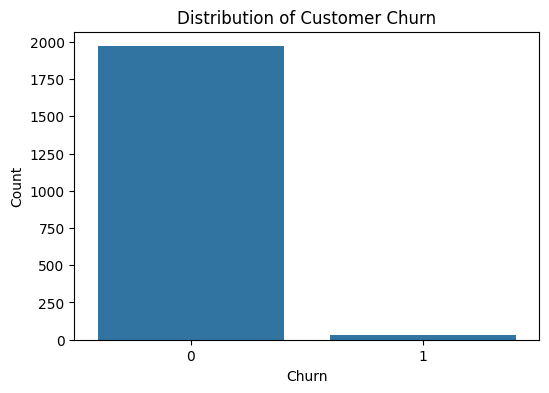

In [22]:
# Visualize Churn Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [23]:
# Display Churn Percentage
churn_percentage = (df['churn'].value_counts(normalize=True)) * 100

print(churn_percentage)

churn
0    98.45
1     1.55
Name: proportion, dtype: float64


#Task 2: Data Preprocessing

In [44]:
# Check Missing Values
df.isnull().sum()

,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0
data_usage_gb,0


In [45]:
#Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

In [46]:
# Define Categorical Columns
categorical_columns = ['region', 'plan_type', 'contract_type', 'payment_method']

In [47]:
# Create Label Encoder Object
label_encoder = LabelEncoder()

In [48]:
# Encode Categorical Columns
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [49]:
# Display Updated Dataset
df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,3,3,0,1,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,4,2,0,4,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,0,3,0,0,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,4,2,0,0,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,2,2,0,2,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [50]:
# Separate Features and Target Variable
X = df.drop("churn", axis=1)
y = df["churn"]

In [51]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

In [52]:
# Create Scaler Object
scaler = StandardScaler()

In [54]:
#Scale the Features
X_scaled = scaler.fit_transform(X)

In [55]:
# Import Train-Test Split
from sklearn.model_selection import train_test_split

In [56]:
# Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
# Check Shape of Training and Testing Data
print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (1600, 15)
Testing Feature Shape: (400, 15)
Training Target Shape: (1600,)
Testing Target Shape: (400,)


#Task 3: Neural Network Model Building

In [61]:
# Imporing Required Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [62]:
# Create Neural Network Model
model = Sequential()

In [65]:
# Add Input Layer and First Hidden Layer
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

In [66]:
# Add Second Hidden Layer
model.add(Dense(32, activation='relu'))

In [67]:
# Add Output Layer
model.add(Dense(1, activation='sigmoid'))

In [68]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [69]:
# Display Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,457 (44.75 KB)

 Trainable params: 11,457 (44.75 KB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Training and Evaluation

In [70]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9563 - loss: 0.2413 - val_accuracy: 0.9781 - val_loss: 0.1270
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0777 - val_accuracy: 0.9781 - val_loss: 0.1058
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0665 - val_accuracy: 0.9781 - val_loss: 0.1003
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0576 - val_accuracy: 0.9781 - val_loss: 0.1059
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9867 - loss: 0.0515 - val_accuracy: 0.9781 - val_loss: 0.1012
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9867 - loss: 0.0458 - val_accuracy: 0.9781 - val_loss: 0.1057
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.0398 - val_accuracy: 0.9781 - val_loss: 0.1094
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9867 - loss: 0.0346 - val_accuracy: 0.9781 - val_los

In [71]:
# Display training accuracy and loss
train_loss = history.history['loss'][-1]
train_accuracy = history.history['accuracy'][-1]

print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)

Training Loss: 9.651177242631093e-05
Training Accuracy: 1.0


In [72]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9800 - loss: 0.2719  


In [73]:
# Display testing accuracy and loss
print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_accuracy)

Testing Loss: 0.2719499468803406
Testing Accuracy: 0.9800000190734863


In [74]:
# Predict values
y_pred = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [75]:
# Convert predictions into binary values
y_pred = (y_pred > 0.5).astype(int)

In [76]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

In [77]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

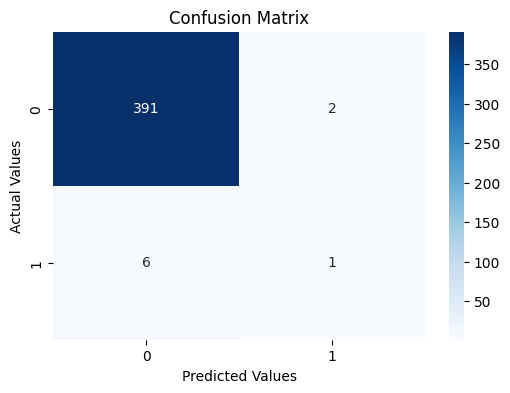

In [78]:
# Display confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")

plt.show()

#Task 5: Hyperparameter Experimentation

In [79]:
# Import Adam optimizer
from tensorflow.keras.optimizers import Adam

# Experiment 1

In [83]:
# Experiment 1 Model

model_1 = Sequential()

model_1.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model_1.add(Dense(1, activation='sigmoid'))

model_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [85]:
# Train Experiment 1

history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [88]:
# Evaluate Experiment 1

loss_1, accuracy_1 = model_1.evaluate(X_test, y_test, verbose=0)

print("Experiment 1 Accuracy:", accuracy_1)

Experiment 1 Accuracy: 0.9825000166893005


# Experiment 2

In [90]:
# Experiment 2 Model

model_2 = Sequential()

model_2.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model_2.add(Dense(32, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))

model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [91]:
# Train Experiment 2

history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [92]:
# Evaluate Experiment 2

loss_2, accuracy_2 = model_2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", accuracy_2)

Experiment 2 Accuracy: 0.9850000143051147


# Experiment 3

In [93]:
# Experiment 3 Model

model_3 = Sequential()

model_3.add(Dense(128, activation='tanh', input_shape=(X_train.shape[1],)))
model_3.add(Dense(64, activation='tanh'))
model_3.add(Dense(32, activation='tanh'))
model_3.add(Dense(1, activation='sigmoid'))

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [94]:
# Train Experiment 3

history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

In [95]:
# Evaluate Experiment 3

loss_3, accuracy_3 = model_3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", accuracy_3)

Experiment 3 Accuracy: 0.9725000262260437


In [96]:
# Create comparison table

comparison_table = pd.DataFrame({
    'Experiment': ['Experiment 1', 'Experiment 2', 'Experiment 3'],
    'Hidden Layers': [1, 2, 3],
    'Neurons': ['32', '64-32', '128-64-32'],
    'Activation Function': ['ReLU', 'ReLU', 'Tanh'],
    'Epochs': [20, 30, 40],
    'Batch Size': [32, 32, 64],
    'Testing Accuracy': [accuracy_1, accuracy_2, accuracy_3]
})

comparison_table

,Experiment,Hidden Layers,Neurons,Activation Function,Epochs,Batch Size,Testing Accuracy
0,Experiment 1,1,32,ReLU,20,32,0.9825
1,Experiment 2,2,64-32,ReLU,30,32,0.9850
2,Experiment 3,3,128-64-32,Tanh,40,64,0.9725


In [99]:
# Save comparison table

comparison_table.to_csv("model_comparison_table.csv", index=False)

# Task 6: Final Reflection
# 1. Role of Weights and Biases
Weights and biases are important parameters in a neural network.
Weights help determine the importance of each input feature, while biases help shift the activation values and improve the flexibility of the model.
During training, these values are continuously updated to reduce prediction error and improve model accuracy.
#2. Importance of Activation Function
Activation functions are required to introduce non-linearity into the neural network.
Without activation functions, the neural network would behave like a simple linear model and would not be able to learn complex patterns from the data.
Functions like ReLU and Sigmoid help the model learn better relationships between inputs and outputs.
#3. Effect of Learning Rate
The learning rate controls how quickly the model updates its weights during training.

If the learning rate is too high, the model may become unstable and fail to reach the optimal solution.
If the learning rate is too low, training becomes very slow and the model may take a long time to converge.

Choosing an appropriate learning rate is important for stable and efficient model training.
#4. Underfitting and Overfitting
The model showed balanced performance between training and testing accuracy, indicating that the model learned meaningful patterns from the dataset.
If training accuracy had been very high and testing accuracy very low, it would indicate overfitting.
If both training and testing accuracy were low, it would indicate underfitting.

Based on the obtained results, the model did not show significant signs of severe underfitting or overfitting.